# Get CTD data from High Res CTD up_and_down

In [27]:
import pandas as pd
import numpy as np

import os
import yaml
import glob

import EcoFOCIpy.io.sbe_ctd_parser as sbe_ctd_parser #<- instrument specific
import EcoFOCIpy.io.ncCFsave as ncCFsave
import EcoFOCIpy.metaconfig.load_config as load_config
import EcoFOCIpy.math.geotools as geotools

In [28]:
sample_data_dir = '/Users/bell/ecoraid/2025/CTDcasts/nw2501/' #root path to cruise directory
ecofocipy_dir = '/Users/bell/Programs/EcoFOCIpy/'

In [29]:
###############################################################
# edit to point to {cruise sepcific} raw datafiles 
datafile = sample_data_dir+'rawconverted/' #<- point to cruise and process all files within
cruise_name = 'NW2501' #no hyphens
cruise_meta_file = sample_data_dir+'logs/NW2501.yaml'
inst_meta_file = sample_data_dir+'logs/EMA_standard_CTD.yaml'
group_meta_file = ecofocipy_dir+'staticdata/institutional_meta_example_ctd.yaml'
inst_shortname = '' #keep as placeholder for now
###############################################################

In [55]:
casts = ['dctd019','dctd043','dctd045']

In [56]:
active_cast = casts[2]
cdepth=250

In [57]:
filename_list = sorted(glob.glob(datafile + f'{active_cast}' + '*.cnv'))

cruise = sbe_ctd_parser.sbe9_11p()
(cruise_data,cruise_header) = cruise.parse(filename_list)

<Axes: >

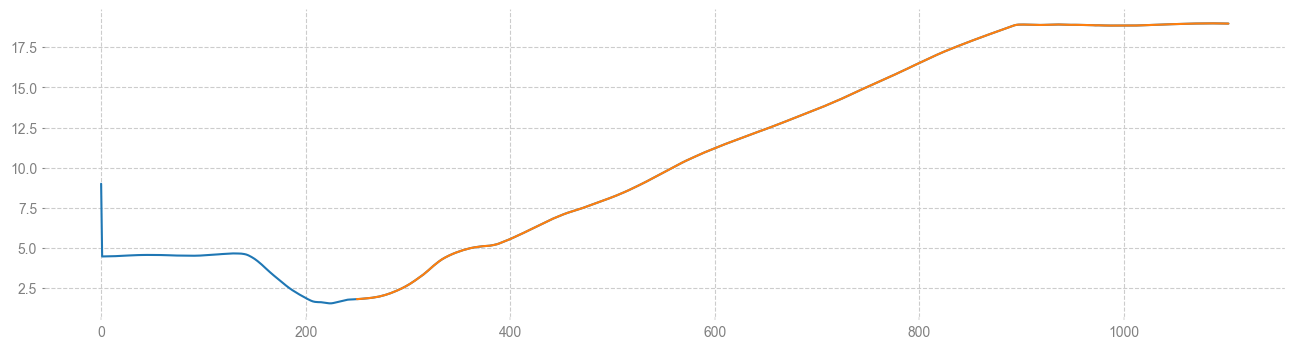

In [58]:
cruise_data[active_cast+'.cnv'].reset_index()['Pressure [dbar]'].plot(figsize=(16,4))
cruise_data[active_cast+'.cnv'].reset_index()['Pressure [dbar]'][cdepth:].plot(figsize=(16,4))

***Using plot above, find shallowest point for cast start***

In [59]:
import pandas as pd
import numpy as np

def bin_pressure_to_midpoints(
    df: pd.DataFrame, 
    pressure_col: str, 
    bin_width: float = 1.0, 
    offset: float = 0.5
) -> pd.DataFrame:
    """
    Bins pressure data and labels the resulting index with the bin midpoints.
    Example: Bins [0.5, 1.5) will be labeled as '1.0'.
    """
    # 1. Define edges based on the offset
    p_min, p_max = df[pressure_col].min(), df[pressure_col].max()
    start_edge = np.floor(p_min - offset) + offset
    end_edge = np.ceil(p_max + offset) + offset
    bin_edges = np.arange(start_edge, end_edge + bin_width, bin_width)
    
    # 2. Perform the binning
    df_temp = df.copy()
    df_temp['bins'] = pd.cut(df_temp[pressure_col], bins=bin_edges, right=False)
    
    # 3. Aggregate
    # observed=True excludes bins with no data, keeping the index lean
    binned_df = df_temp.groupby('bins', observed=True).mean()
    
    # 4. Transform Interval Index to Midpoint Index
    # .mid is a property of the pandas Interval object
    binned_df.index = binned_df.index.map(lambda x: x.mid).astype(float)
    # binned_df.drop(columns=['pressure_col'])
    binned_df.index.name = f"{pressure_col}"
    
    return binned_df

# Usage
# df_final = bin_pressure_to_midpoints(df_raw, 'pressure')
cruise_data[active_cast+'.cnv'] = bin_pressure_to_midpoints(cruise_data[active_cast+'.cnv'].reset_index()[cdepth:], 'Pressure [dbar]', bin_width=1.0, offset=0.5)


In [60]:
cruise_data[active_cast+'.cnv']

,Pressure [dbar],c0mS/cm,c1mS/cm,flECO-AFL,sbeox0V,sbeox1V,t090C,t190C,par/sat/log,flag
Pressure [dbar],,,,,,,,,,
2.0,2.039289,24.310049,24.325547,1.309629,2.449431,3.372880,10.219436,10.213164,237.949556,1.0
3.0,2.970500,24.321060,24.322106,1.290950,2.442358,3.665767,10.221204,10.221054,120.362375,1.0
4.0,4.068857,24.309144,24.321626,1.282962,2.431138,3.858095,10.206152,10.208900,74.424048,1.0
5.0,5.036305,24.368657,24.333035,1.253988,2.419237,4.076188,10.194081,10.196915,58.825525,1.0
6.0,6.004394,24.457220,24.452196,1.273852,2.415376,4.201758,10.201194,10.202809,38.387576,1.0
7.0,7.052950,24.673601,24.647016,1.233762,2.414550,4.180347,10.202803,10.202730,24.914000,1.0
8.0,7.984073,24.912644,24.888360,1.291329,2.405339,3.750271,10.224568,10.224159,18.119098,1.0
9.0,8.979968,25.473885,25.381185,1.278652,2.400597,3.428913,10.178316,10.185232,12.071942,1.0
10.0,10.012161,26.096233,26.074132,1.162487,2.392329,3.271281,10.103574,10.103261,8.187384,1.0


In [61]:
#cruise info
with open(cruise_meta_file) as file:
    cruise_config = yaml.full_load(file)

#instrument info
with open(inst_meta_file) as file:
    inst_config = yaml.full_load(file)

#institutional info
with open(group_meta_file) as file:
    group_config = yaml.full_load(file)

In [62]:
cruise_data[active_cast+'.cnv'] = cruise_data[active_cast+'.cnv'].rename(columns={
                    't090C':'temperature_ch1',
                    't190C':'temperature_ch2',
                    'sal00':'salinity_ch1',
                    'sal11':'salinity_ch2',
                    'sbox0Mm/Kg':'oxy_conc_ch1',
                    'sbeox0ML/L':'oxy_concM_ch1',
                    'sbeox0PS':'oxy_percentsat_ch1',
                    'sbox1Mm/Kg':'oxy_conc_ch2',
                    'sbeox1ML/L':'oxy_concM_ch2',
                    'sbeox1PS':'oxy_percentsat_ch2',
                    'sigma-t00':'sigma_t_ch1',
                    'sigma-t11':'sigma_t_ch2',
                    'flECO-AFL':'chlor_fluorescence',
                    'turbWETntu0':'turbidity',
                    'cstarat0':'Attenuation',
                    'cstartr0':'Transmittance',
                    'par':'par',
                    'par/sat/log':'par',
                    'empty':'empty', #this will be ignored
                    'flag':'flag'})

cruise_data[active_cast+'.cnv'].index.rename('depth',inplace=True)
#cruise_data[cast].sample()

cruise_data_nc = ncCFsave.EcoFOCI_CFnc(df=cruise_data[active_cast+'.cnv'], 
                            instrument_yaml=inst_config, 
                            operation_yaml=cruise_config,
                            operation_type='ctd')
cruise_data_nc.expand_dimensions(dim_names=['latitude','longitude','time'],geophys_sort=False)
cruise_data_nc.variable_meta_data(variable_keys=list(cruise_data[active_cast+'.cnv'].columns.values),drop_missing=True)
cruise_data_nc.dimension_meta_data(variable_keys=['depth','latitude','longitude'])
cruise_data_nc.temporal_geospatioal_meta_data_ctd(positiveE=False,conscastno=(f'c{(active_cast+'.cnv').split('.')[0].split('dc')[1:][0]}'))

cruise_data_nc.var_qcflag_init(dim_names=['depth','latitude','longitude','time'])

#interp to sfc for list of vars
try:
    cruise_data_nc.interp2sfc(novars=['par'])
except:
    pass

#add global attributes
cruise_data_nc.deployment_meta_add(conscastno=f'C{(active_cast+'.cnv').split('.')[0].split('dc')[1:][0].upper()}')
cruise_data_nc.get_xdf()

#add instituitonal global attributes
cruise_data_nc.institution_meta_add(group_config)

#add creation date/time - provenance data
cruise_data_nc.provinance_meta_add()

#provide intial qc status field
cruise_data_nc.qc_status(qc_status='unknown')

cast_label = (active_cast+'.cnv').split('.')[0].split('d')[-1]
cruise_data_nc.xarray2netcdf_save(xdf = cruise_data_nc.get_xdf(),
                        filename=sample_data_dir+cruise_name+'c'+cast_label.zfill(3)+'_ctd.nc',format="NETCDF3_CLASSIC")
#generate editable csv files
to_edit = True
if to_edit:
    cruise_data_nc.get_xdf().to_dataframe().to_csv(sample_data_dir+cruise_name+'c'+cast_label.zfill(3)+'_ctd.to_edit.csv')  
    outfilename = sample_data_dir+cruise_name+'c'+cast_label.zfill(3)+'_ctd.to_edit.csv'

## Generate Plots


### Make General Plots
- 1:1 plots for paired instruments for each cast (tells if a sensor failed)
- TS_Sigmat, Chlor/Par/Turb, Oxy,Temp
- T/S property property plot
- upcast/downcast plt

In [63]:
# Following routines will eventually get ported to ecofocipy as subroutines to be called

import EcoFOCIpy.plots.sbe_ctd_plots as sbe_ctd_plots
import seawater as sw

def sigmat_update(salinity=None,temperature=None):
    '''
    Changes to T or S (commonly to despike values or apply a salinity offset) will need corresponding changes in sigmat
    '''
    # calculate sigmaT at 0db gauge pressure (s, t, p=0)
    sigt = (sw.eos80.dens0(s=salinity, t=temperature) - 1000)
    
    return sigt


In [64]:
calc_sigmat = True


ctd_df = cruise_data_nc.get_xdf().to_dataframe()

if calc_sigmat:
    #update sigmat (or calculate it I suppose)
    sigup = sigmat_update(salinity=ctd_df.salinity_ch1,
                          temperature=ctd_df.temperature_ch1)
    ctd_df['sigma_t_ch1'] = sigup
    
    sigup2 = sigmat_update(salinity=ctd_df.salinity_ch2,
                          temperature=ctd_df.temperature_ch2)
    ctd_df['sigma_t_ch2'] = sigup2   
sbe_p = sbe_ctd_plots.CTDProfilePlot()
plt,fig =sbe_p.plot3var(varname=['temperature_ch1','temperature_ch2','salinity_ch1','salinity_ch2','sigma_t_ch1','sigma_t_ch2'],
                  xdata=[ctd_df.temperature_ch1,ctd_df.temperature_ch2,ctd_df.salinity_ch1,ctd_df.salinity_ch2,ctd_df.sigma_t_ch1,ctd_df.sigma_t_ch2],
                  ydata=ctd_df.index.get_level_values('depth'),
                  secondary=True,
                  xlabel=['Temperature','Salinity','Sigma-T'])

DefaultSize = fig.get_size_inches()
fig.set_size_inches( (DefaultSize[0], DefaultSize[1]*3) )
plt.savefig(outfilename.replace('.csv','_TempSalSigmat.png'))
plt.close(fig)


AttributeError: 'DataFrame' object has no attribute 'salinity_ch1'

In [40]:
ctd_df = cruise_data_nc.get_xdf().to_dataframe()

sbe_p = sbe_ctd_plots.CTDProfilePlot()
plt,fig =sbe_p.plot2var(varname=['temperature_ch1','temperature_ch2','oxy_percentsat_ch1','oxy_percentsat_ch2'],
                  xdata=[ctd_df.temperature_ch1,ctd_df.temperature_ch2,ctd_df.oxy_percentsat_ch1,ctd_df.oxy_percentsat_ch2],
                  ydata=ctd_df.index.get_level_values('depth'),
                  secondary=True,
                  xlabel=['Temperature','Oxygen Saturation'])

DefaultSize = fig.get_size_inches()
fig.set_size_inches( (DefaultSize[0], DefaultSize[1]*3) )
plt.savefig(outfilename.replace('.csv','_TempOxy.png'))
plt.close(fig)


In [41]:
ctd_df = cruise_data_nc.get_xdf().to_dataframe()

sbe_p = sbe_ctd_plots.CTDProfilePlot()
plt,fig =sbe_p.plot2var(varname=['chlor_fluorescence','','par'],
                  xdata=[ctd_df.chlor_fluorescence,np.array([]),ctd_df.par,np.array([])],
                  ydata=ctd_df.index.get_level_values('depth'),
                  secondary=False,
                  xlabel=['Fluor','Par'])

DefaultSize = fig.get_size_inches()
fig.set_size_inches( (DefaultSize[0], DefaultSize[1]*3) )
plt.savefig(outfilename.replace('.csv','_TurbFluorPAR.png'))
plt.close(fig)
